# Settings

In [1]:
options(scipen=999)
pacman::p_load(plyr,dplyr, stringr, data.table, tidyr,circlize,
               pheatmap, colorRamps, gridExtra, ggplot2, ggrepel, RColorBrewer,ComplexHeatmap,vioplot,ggforce,
              gridExtra, ggplot2, ggrepel, RColorBrewer,ComplexHeatmap,vioplot,grid, patchwork, grid, ggh4x)


## Directories

In [2]:
# Set working directories
base.dir =  "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/"
assets.dir = paste(base.dir, "Assets/", sep = "") 
results.dir = paste(base.dir, "Results/corrected/", sep = "")
permutation.result.dir = paste(base.dir, "Results/corrected.permutation.test/", sep = "")


# Databases
cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"
Gaulton.db.dir = "/nfs/lab/Luca/Assets/LR.Database/GaultonDB_V2.txt"

permutations.test.tmp.dir = paste(permutation.result.dir, "TMP/", sep = "")
permutations.test.res.dir = paste(permutation.result.dir, "Results/", sep = "")

cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"

## Variables

In [3]:
# conditions
condition.ls = c("ND", "Aab", "T1D_early","T1D_late")

colors.conditions = c("ND" = "#85EF1B",
                      "Aab" = "#EFEF1B",
                      "T1D_early" = "#EF851B",
                      "T1D_late" = "#EF1B1B")

# Contrasts
Contrast_1 = c(condition.ls[2], condition.ls[3], condition.ls[4])
Contrast_2 = c(condition.ls[1], condition.ls[1], condition.ls[1])

# Celltypes and compartments
Endocrine = c('Alpha', 'Beta', 'Delta')
Exocrine = c('Acinar1_2_6','Acinar_3','Acinar_4','Acinar_5','Ductal','MUC5b_Ductal')
Immune = c('Tcells','Macrophage')
Endothelial = c('Endothelial')
Stromal = c('Activated_Stellate','Quiescent_Stellate')

cell.pop.order = c(Endocrine, Exocrine, Immune, Endothelial, Stromal)
rev.cell.pop.order = c(rev(Stromal), rev(Endothelial), rev(Immune), rev(Exocrine), rev(Endocrine), use.names = TRUE)

compartment = cell.pop.order
compartment = ifelse(compartment  %in%  Endocrine, "Endocrine", 
                 ifelse(compartment  %in%  Exocrine, "Exocrine",
                        ifelse(compartment  %in%  Immune, "Immune",
                               ifelse(compartment  %in%  Endothelial, "Endothelial", "Stromal"))))

Cellpop.compartment = as.data.frame(cbind(cell.pop.order, compartment))
Cellpop.compartment$compartment = factor(Cellpop.compartment$compartment, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))
colnames(Cellpop.compartment)[1] = "Celltype"

colors.compartments = c('Endocrine'='#26bfbf',
           'Exocrine'='#ed872d',
           'Immune'='#3F98E0',
           'Endothelial'='#800080',
           'Stromal'='#F5DE6C')

colors.celltypes = c('Alpha' = "#26bfbf",
                     'Beta' = "#26bfbf",
                     'Delta' = "#26bfbf",
                     'Acinar1_2_6' = "#ed872d",
                     'Acinar_3' = "#ed872d",
                     'Acinar_4' = "#ed872d",
                     'Acinar_5' = "#ed872d",
                     'Ductal' = "#ed872d",
                     'MUC5b_Ductal' = "#ed872d",
                     'Tcells' = "#3F98E0",
                     'Macrophage' = "#3F98E0",
                     'Endothelial' = "#800080",
                     'Activated_Stellate' = "#F5DE6C",
                     'Quiescent_Stellate' = "#F5DE6C")

Cellpop.compartment$colors.compartments = compartment
Cellpop.compartment$colors.compartments = mapvalues(Cellpop.compartment$colors.compartments, names(colors.compartments), colors.compartments, warn_missing = TRUE)
gaps.compartments = c(3, 9, 11, 12)

# Permutation test

## Observations

In [36]:
LR.data.consensus.sig.thresh = read.table(paste(results.dir,
                                               "LR.data.consensus.sig.thresh.txt", sep = ""),
                                          sep = "\t", stringsAsFactors = F, header = T)
LR.data.consensus.sig.thresh = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$target %in% cell.pop.order, ]
LR.data.consensus.sig.thresh = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$source %in% cell.pop.order, ]

In [37]:
# Split LR pairs
LR.data.ND = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[1], ]
LR.data.AAB = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[2], ]
LR.data.ETD = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[3], ]
LR.data.LTD = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[4], ]
nrow(LR.data.consensus.sig.thresh)
# Print stats
message("LR pairs in ND: ", nrow(LR.data.ND))
message("LR pairs in AAB : ", nrow(LR.data.AAB))
message("LR pairs in Early T1D: ", nrow(LR.data.ETD))
message("LR pairs in Late T1D: ", nrow(LR.data.LTD))

[1] 87650

LR pairs in ND: 27139

LR pairs in AAB : 27459

LR pairs in Early T1D: 18179

LR pairs in Late T1D: 14873



In [38]:
head(LR.data.consensus.sig.thresh, n=1)

,ligand,source,target,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,⋯,FDR,interaction.id,compartment.source,compartment.target,Type,Mode.of.Action,Signaling,Functional.classification,Functional.sub.classification,Gene.Family
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ADCYAP1,Beta,Quiescent_Stellate,ADCYAP1R1,0.00006164112,0.0001,ADCYAP1_ADCYAP1R1,ADCYAP1 - ADCYAP1R1,PACAP,Secreted Signaling,⋯,0.000153715,Beta--Quiescent_Stellate--ADCYAP1--ADCYAP1R1,Endocrine,Stromal,Ligand,Secreted Signaling,Hormones & Neuropeptides,Hormone/Neuropeptide,Other,PACAP Family


In [39]:
condition.sizes = c(nrow(LR.data.ND), nrow(LR.data.AAB), nrow(LR.data.ETD), nrow(LR.data.LTD))
condition.sizes

condition.size_1 = c(condition.sizes[2], condition.sizes[3], condition.sizes[4])
condition.size_2 = c(condition.sizes[1], condition.sizes[1], condition.sizes[1])

[1] 27139 27459 18179 14873

In [40]:
nsim = 100

In [41]:
# Create a named vector that maps conditions to sizes
condition_mapping <- c("ND" = condition.sizes[1], "Aab" = condition.sizes[2],
                       "T1D_early" = condition.sizes[3], "T1D_late" = condition.sizes[4])

In [42]:
LR.data.consensus.use = LR.data.consensus.sig.thresh
nrow(LR.data.consensus.use)

[1] 87650

In [43]:
head(LR.data.consensus.use[c(1,2,3,12,14,5,15,16)], n = 2)

,ligand,source,target,condition,interaction.id,prob,compartment.source,compartment.target
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,ADCYAP1,Beta,Quiescent_Stellate,Aab,Beta--Quiescent_Stellate--ADCYAP1--ADCYAP1R1,0.00006164112,Endocrine,Stromal
2,ADCYAP1,Beta,Activated_Stellate,Aab,Beta--Activated_Stellate--ADCYAP1--ADCYAP1R1,0.00022605242,Endocrine,Stromal


In [44]:
# Perform the aggregation
aggregated_data <- aggregate(prob ~ source + target + condition + compartment.source + compartment.target, LR.data.consensus.use, sum)
# normalize by condition size
aggregated_data <- aggregated_data %>%
  dplyr::mutate(prob.norm = prob / condition_mapping[as.character(condition)]) %>%
  dplyr::mutate(condition.size = condition_mapping[as.character(condition)])
aggregated_data$y = 1
aggregated_data$compartment.source = factor(aggregated_data$compartment.source, levels = unique(compartment))
aggregated_data$compartment.target = factor(aggregated_data$compartment.target, levels = unique(compartment))
aggregated_data$source.target = paste(aggregated_data$source, aggregated_data$target, sep = "-")
sorce.target.consensus = as.data.frame(unique(aggregated_data$source.target))
colnames(sorce.target.consensus) = "source.target"

In [45]:
head(filter(aggregated_data, condition == "ND"))

,source,target,condition,compartment.source,compartment.target,prob,prob.norm,condition.size,y,source.target
,<chr>,<chr>,<chr>,<fct>,<fct>,<dbl>,<dbl>,<int>,<dbl>,<chr>
1,Alpha,Alpha,ND,Endocrine,Endocrine,0.2223758,0.000008193956,27139,1,Alpha-Alpha
2,Beta,Alpha,ND,Endocrine,Endocrine,0.2253616,0.000008303976,27139,1,Beta-Alpha
3,Delta,Alpha,ND,Endocrine,Endocrine,0.1951159,0.000007189502,27139,1,Delta-Alpha
4,Alpha,Beta,ND,Endocrine,Endocrine,0.2376266,0.000008755908,27139,1,Alpha-Beta
5,Beta,Beta,ND,Endocrine,Endocrine,0.2322275,0.000008556967,27139,1,Beta-Beta
6,Delta,Beta,ND,Endocrine,Endocrine,0.2136667,0.000007873051,27139,1,Delta-Beta


In [46]:
diff.obs = list()
abs.diff.obs = list()

for (i in seq_along(Contrast_1)){
    LR.data.use <- aggregated_data
    # Subset for the contrast
    contrast = c(Contrast_1[i], Contrast_2[i])
    message("Processing ", Contrast_1[i], " vs ", Contrast_2[i])
    LR.data.c1 = LR.data.use[LR.data.use$condition %in% contrast[1], ]
    LR.data.c2 = LR.data.use[LR.data.use$condition %in% contrast[2], ]
    # Complete dataset
    LR.data.c1 = merge(LR.data.c1, sorce.target.consensus, by = "source.target", all.y = TRUE)
    LR.data.c2 = merge(LR.data.c2, sorce.target.consensus, by = "source.target", all.y = TRUE)
    # Replace NA with 0
    LR.data.c1$prob[is.na(LR.data.c1$prob.norm)] = 0
    LR.data.c2$prob[is.na(LR.data.c2$prob.norm)] = 0
    # Correct condition column
    LR.data.c1$condition = contrast[1]
    LR.data.c2$condition = contrast[2]    
    message("Distribution of interactions in contrast: \n",
            Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
            Contrast_2[i], ": ", nrow(LR.data.c2))
    # Order 
    LR.data.c1 = dplyr::arrange(LR.data.c1, source.target)
    LR.data.c2 = dplyr::arrange(LR.data.c2, source.target) 
    
    # Compute difference
    diff = LR.data.c1$prob.norm - LR.data.c2$prob.norm
    diff.obs[[i]] = data.frame(source.target = LR.data.c1$source.target, condition = contrast[1],
                              diff = diff, abs.diff = abs(diff))
}

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 196
ND: 196

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 196
ND: 196

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 196
ND: 196



## Simulations

In [47]:
setwd(permutations.test.tmp.dir)
sim.list <- dir(pattern = "_DFnet.txt")

In [48]:
# Create tables to fill up
diff.sim = list()
random.success.table = list()
# Create tables with right sets of of rows
random.success.table[[1]] = data.frame(source.target = LR.data.c1$source.target)
random.success.table[[2]] = data.frame(source.target = LR.data.c1$source.target)
random.success.table[[3]] = data.frame(source.target = LR.data.c1$source.target)

for (s.i in seq_along(sim.list)){
        # Get files
        print(paste0("Processing: ", sim.list[s.i]))
        # Load simulation data
        LR.data.use <- read.table(sim.list[s.i], sep = "\t", stringsAsFactors = F, header = T)
        # Create a named vector that maps conditions to sizes
        condition.sim_mapping <- c("ND" = nrow(LR.data.use[LR.data.use$condition == "ND",]),
                               "Aab" = nrow(LR.data.use[LR.data.use$condition == "Aab",]),          
                               "T1D_early" = nrow(LR.data.use[LR.data.use$condition == "T1D_early",]),           
                               "T1D_late" = nrow(LR.data.use[LR.data.use$condition == "T1D_late",]))
        message("\t Detected: ", nrow(LR.data.use), " interactions")
        message(" Normalizing ND: ", condition.sim_mapping[1],
                "\n Normalizing AAB: ", condition.sim_mapping[2],
                "\n Normalizing ETD: ", condition.sim_mapping[3],
                "\n Normalizing LTD: ", condition.sim_mapping[4]
               )        
        # Perform the aggregation
        aggregated_data.sim <- aggregate(prob ~ source + target + condition, LR.data.use, sum)
        # normalize by condition size
        aggregated_data.sim <- aggregated_data.sim %>%
          dplyr::mutate(prob.norm = prob / condition.sim_mapping[as.character(condition)]) %>%
          dplyr::mutate(condition.size = condition_mapping[as.character(condition)])
        aggregated_data.sim$y = 1
        aggregated_data.sim$source.target = paste(aggregated_data.sim$source, aggregated_data.sim$target, sep = "-")
        sorce.target.consensus = as.data.frame(unique(aggregated_data.sim$source.target))
        colnames(sorce.target.consensus) = "source.target"
        for (i in seq_along(Contrast_1)){
                        # Subset for the contrast
                        contrast = c(Contrast_1[i], Contrast_2[i])
                        message("Processing ", Contrast_1[i], " vs ", Contrast_2[i])
                        LR.data.c1 = aggregated_data.sim[aggregated_data.sim$condition %in% contrast[1], ]
                        LR.data.c2 = aggregated_data.sim[aggregated_data.sim$condition %in% contrast[2], ]
                        # Complete dataset
                        LR.data.c1 = merge(LR.data.c1, sorce.target.consensus, by = "source.target", all.y = TRUE)
                        LR.data.c2 = merge(LR.data.c2, sorce.target.consensus, by = "source.target", all.y = TRUE)
                        # Replace NA with 0
                        LR.data.c1$prob[is.na(LR.data.c1$prob.norm)] = 0
                        LR.data.c2$prob[is.na(LR.data.c2$prob.norm)] = 0
                        # Correct condition column
                        LR.data.c1$condition = contrast[1]
                        LR.data.c2$condition = contrast[2]    
                        message("Distribution of interactions in contrast: \n",
                                Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
                                Contrast_2[i], ": ", nrow(LR.data.c2))

                        # Order 
                        LR.data.c1 = arrange(LR.data.c1, source.target)
                        LR.data.c2 = arrange(LR.data.c2, source.target) 

                        # Compute difference
                        diff = LR.data.c1$prob.norm - LR.data.c2$prob.norm
                        diff.sim[[i]] = data.frame(source.target = LR.data.c1$source.target, condition = contrast[1],
                                                  diff = diff, abs.diff = abs(diff))
                        random.success = diff.sim[[i]]$abs.diff > diff.obs[[i]]$abs.diff
                        random.success.table[[i]] = cbind(random.success.table[[i]], random.success)
                        colnames(random.success.table[[i]])[ncol(random.success.table[[i]])] = s.i  
                }
}

[1] "Processing: CellChat_Permutation_n1_DFnet.txt"


	 Detected: 99555 interactions

 Normalizing ND: 22024
 Normalizing AAB: 27464
 Normalizing ETD: 26560
 Normalizing LTD: 23507

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 196
ND: 196

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 196
ND: 196

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 196
ND: 196



[1] "Processing: CellChat_Permutation_n10_DFnet.txt"


	 Detected: 100481 interactions

 Normalizing ND: 27308
 Normalizing AAB: 25931
 Normalizing ETD: 23769
 Normalizing LTD: 23473

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 196
ND: 196

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 196
ND: 196

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 196
ND: 196



[1] "Processing: CellChat_Permutation_n100_DFnet.txt"


...

	 Detected: 100999 interactions

 Normalizing ND: 25650
 Normalizing AAB: 26576
 Normalizing ETD: 25895
 Normalizing LTD: 22878

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 196
ND: 196

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 196
ND: 196

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 196
ND: 196



[1] "Processing: CellChat_Permutation_n98_DFnet.txt"


	 Detected: 99113 interactions

 Normalizing ND: 27409
 Normalizing AAB: 24931
 Normalizing ETD: 22034
 Normalizing LTD: 24739

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 196
ND: 196

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 196
ND: 196

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 196
ND: 196



[1] "Processing: CellChat_Permutation_n99_DFnet.txt"


	 Detected: 100786 interactions

 Normalizing ND: 28311
 Normalizing AAB: 24313
 Normalizing ETD: 24495
 Normalizing LTD: 23667

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 196
ND: 196

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 196
ND: 196

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 196
ND: 196



In [49]:
# Wrap up test results
for (i in seq_along(diff.obs)){
    message("Processing contrast #", i)
    diff.obs[[i]]$random.success = rowSums(random.success.table[[i]] == "TRUE", na.rm = TRUE)
    diff.obs[[i]]$pvalue = diff.obs[[i]]$random.success/nsim
    # correct pvalues of what had no difference to begin with
    diff.obs[[i]]$pvalue = replace(diff.obs[[i]]$pvalue, diff.obs[[i]]$diff == 0, 1)
    # calculate FDR
    diff.obs[[i]]$pvalue[diff.obs[[i]]$pvalue == 0] = 0.0001
    diff.obs[[i]]$FDR = p.adjust(diff.obs[[i]]$pvalue, 'BH')
    # counting stars
    diff.obs[[i]]$stars = diff.obs[[i]]$FDR
    diff.obs[[i]]$stars[diff.obs[[i]]$FDR > 0.1]<-""
    diff.obs[[i]]$stars[diff.obs[[i]]$FDR < 0.1]<-"1"
    diff.obs[[i]]$stars[diff.obs[[i]]$FDR < 0.05]<-"2"
    diff.obs[[i]]$stars[diff.obs[[i]]$FDR < 0.01]<-"3"
    # Apply linear transformation
    diff.obs[[i]]$diff = diff.obs[[i]]$diff * 10000
    diff.obs[[i]]$abs.diff = diff.obs[[i]]$abs.diff * 10000
    file.name = paste(permutations.test.res.dir, "Permutation.test_cellpairs.FDR.", Contrast_1[i], ".res", sep = "")
    write.table(diff.obs[[i]], file.name, sep = "\t", quote = F, col.names=T, row.names = T) 
}

Processing contrast #1

Processing contrast #2

Processing contrast #3



In [50]:
head(diff.obs[[i]])

,source.target,condition,diff,abs.diff,random.success,pvalue,FDR,stars
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Acinar1_2_6-Acinar1_2_6,T1D_late,-0.012134088,0.012134088,68,0.6800,0.7704046243,
2,Acinar1_2_6-Acinar_3,T1D_late,0.009970148,0.009970148,57,0.5700,0.6730120482,
3,Acinar1_2_6-Acinar_4,T1D_late,0.003265587,0.003265587,84,0.8400,0.8804278075,
4,Acinar1_2_6-Acinar_5,T1D_late,0.006414298,0.006414298,63,0.6300,0.7263529412,
5,Acinar1_2_6-Activated_Stellate,T1D_late,0.045560293,0.045560293,0,0.0001,0.0001921569,3
6,Acinar1_2_6-Alpha,T1D_late,0.001235331,0.001235331,76,0.7600,0.8229834254,


In [51]:
# Merge results together in 1 table
stars = data.frame(source.target = LR.data.c1$source.target,
                  ND = "", 
                  Aab = diff.obs[[1]]$stars,
                  T1D_early = diff.obs[[2]]$stars,
                  T1D_late = diff.obs[[3]]$stars)
file.name = paste(permutations.test.res.dir, "Permutation.test_cellpairs.res", sep = "")
write.table(stars, file.name, sep = "\t", quote = F, col.names=T, row.names = T) 

In [52]:
head(stars)

,source.target,ND,Aab,T1D_early,T1D_late
,<chr>,<chr>,<chr>,<chr>,<chr>
1,Acinar1_2_6-Acinar1_2_6,,,,
2,Acinar1_2_6-Acinar_3,,,,
3,Acinar1_2_6-Acinar_4,,,,
4,Acinar1_2_6-Acinar_5,,,,
5,Acinar1_2_6-Activated_Stellate,,,,3
6,Acinar1_2_6-Alpha,,,1,


# Plot

In [16]:
file = paste(permutations.test.res.dir, "Permutation.test_cellpairs.res", sep = "")
cellpairs.stars = read.table(file, sep = "\t", stringsAsFactors = F, header = T)
# remove NAs
cellpairs.stars[is.na(cellpairs.stars)] = ""
cellpairs.stars = gather(cellpairs.stars, condition, stars, 2:5)

# merge to have same rows as the graph - removing sorce.target that don't show up in each condition
aggregated_data = merge(cellpairs.stars, aggregated_data, by = c("source.target", "condition"), all = FALSE)
aggregated_data$condition = factor(aggregated_data$condition, levels = c("ND", "Aab", "T1D_early","T1D_late"))
# apply linear transformation
aggregated_data$prob.norm = aggregated_data$prob.norm * 10000
head(aggregated_data)

,source.target,condition,stars,source,target,compartment.source,compartment.target,prob,prob.norm,condition.size,y
,<chr>,<fct>,<chr>,<chr>,<chr>,<fct>,<fct>,<dbl>,<dbl>,<int>,<dbl>
1,Acinar_3-Acinar_3,Aab,,Acinar_3,Acinar_3,Exocrine,Exocrine,0.09225854,0.03359865,27459,1
2,Acinar_3-Acinar_3,ND,,Acinar_3,Acinar_3,Exocrine,Exocrine,0.10495077,0.03867157,27139,1
3,Acinar_3-Acinar_3,T1D_early,,Acinar_3,Acinar_3,Exocrine,Exocrine,0.06001346,0.03301252,18179,1
4,Acinar_3-Acinar_3,T1D_late,,Acinar_3,Acinar_3,Exocrine,Exocrine,0.06436021,0.04327318,14873,1
5,Acinar_3-Acinar_4,Aab,,Acinar_3,Acinar_4,Exocrine,Exocrine,0.08210003,0.02989913,27459,1
6,Acinar_3-Acinar_4,ND,,Acinar_3,Acinar_4,Exocrine,Exocrine,0.07532382,0.02775483,27139,1


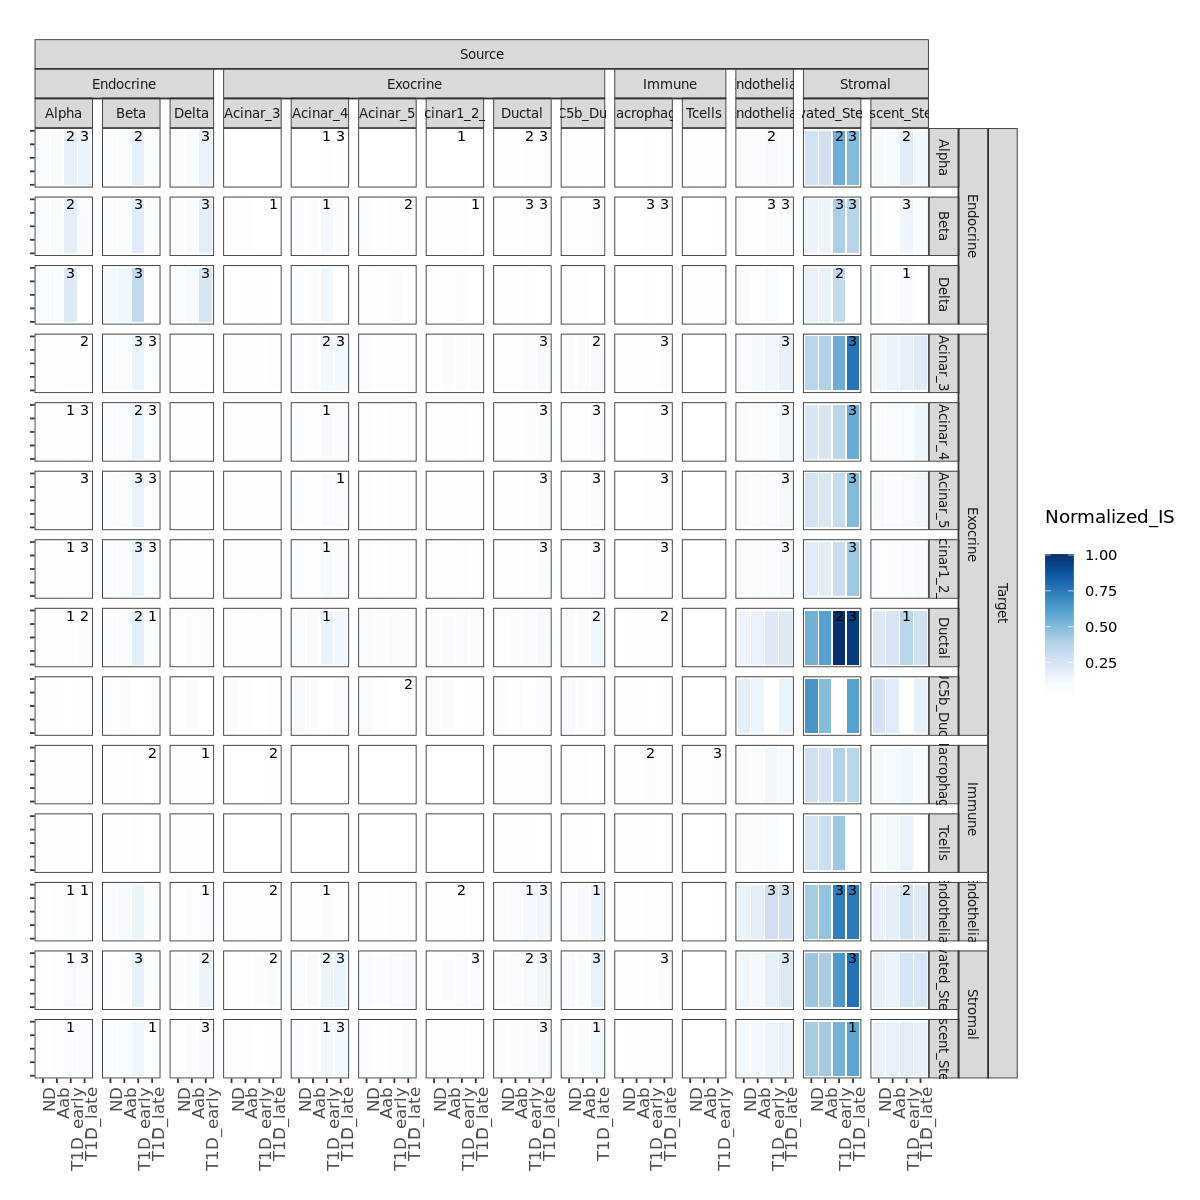

In [17]:
# Set plot size
options(repr.plot.width=10, repr.plot.height=10)

# Define the color palette
color_palette <- colorRampPalette(brewer.pal(9,"Blues"))

# Create the plot
ggplot(aggregated_data, aes(x = condition, y = y, fill = prob.norm, label = stars)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_gradientn(colors = c("white", color_palette(10))) +
  theme_bw() +
  theme(panel.grid = element_blank(),
        axis.text.y = element_blank(),
            strip.text.x = element_text(size = 8),
            strip.text.y = element_text(size = 8),        
        axis.text.x = element_text(angle = 90, hjust = 1, size = 10)) +  
  labs(x = "", y = "", fill = "Normalized_IS \n", title = "") +
  facet_nested(cols = vars("Source", compartment.source, source),
               rows = vars("Target", compartment.target, target), scales = "free", space = "free")+
                  geom_text(vjust = 1, size = 3)

In [18]:
df_normalized <- aggregated_data %>%
      dplyr::group_by(source.target) %>%
      dplyr::mutate(zscore = scale(prob.norm)) %>%
      ungroup()

In [19]:
filter(df_normalized, source == "Macrophage" & target == "Beta")

source.target,condition,stars,source,target,compartment.source,compartment.target,prob,prob.norm,condition.size,y,zscore
<chr>,<fct>,<chr>,<chr>,<chr>,<fct>,<fct>,<dbl>,<dbl>,<int>,<dbl>,"<dbl[,1]>"
Macrophage-Beta,Aab,,Macrophage,Beta,Immune,Endocrine,0.03179037,0.011577396,27459,1,-0.6525537
Macrophage-Beta,ND,,Macrophage,Beta,Immune,Endocrine,0.02391915,0.008813569,27139,1,-1.0447077
Macrophage-Beta,T1D_early,3,Macrophage,Beta,Immune,Endocrine,0.03841431,0.021131147,18179,1,0.7030091
Macrophage-Beta,T1D_late,3,Macrophage,Beta,Immune,Endocrine,0.03448123,0.023183774,14873,1,0.9942523


In [20]:
min(df_normalized$zscore)
max(df_normalized$zscore)

[1] -1.440429

[1] 1.496249

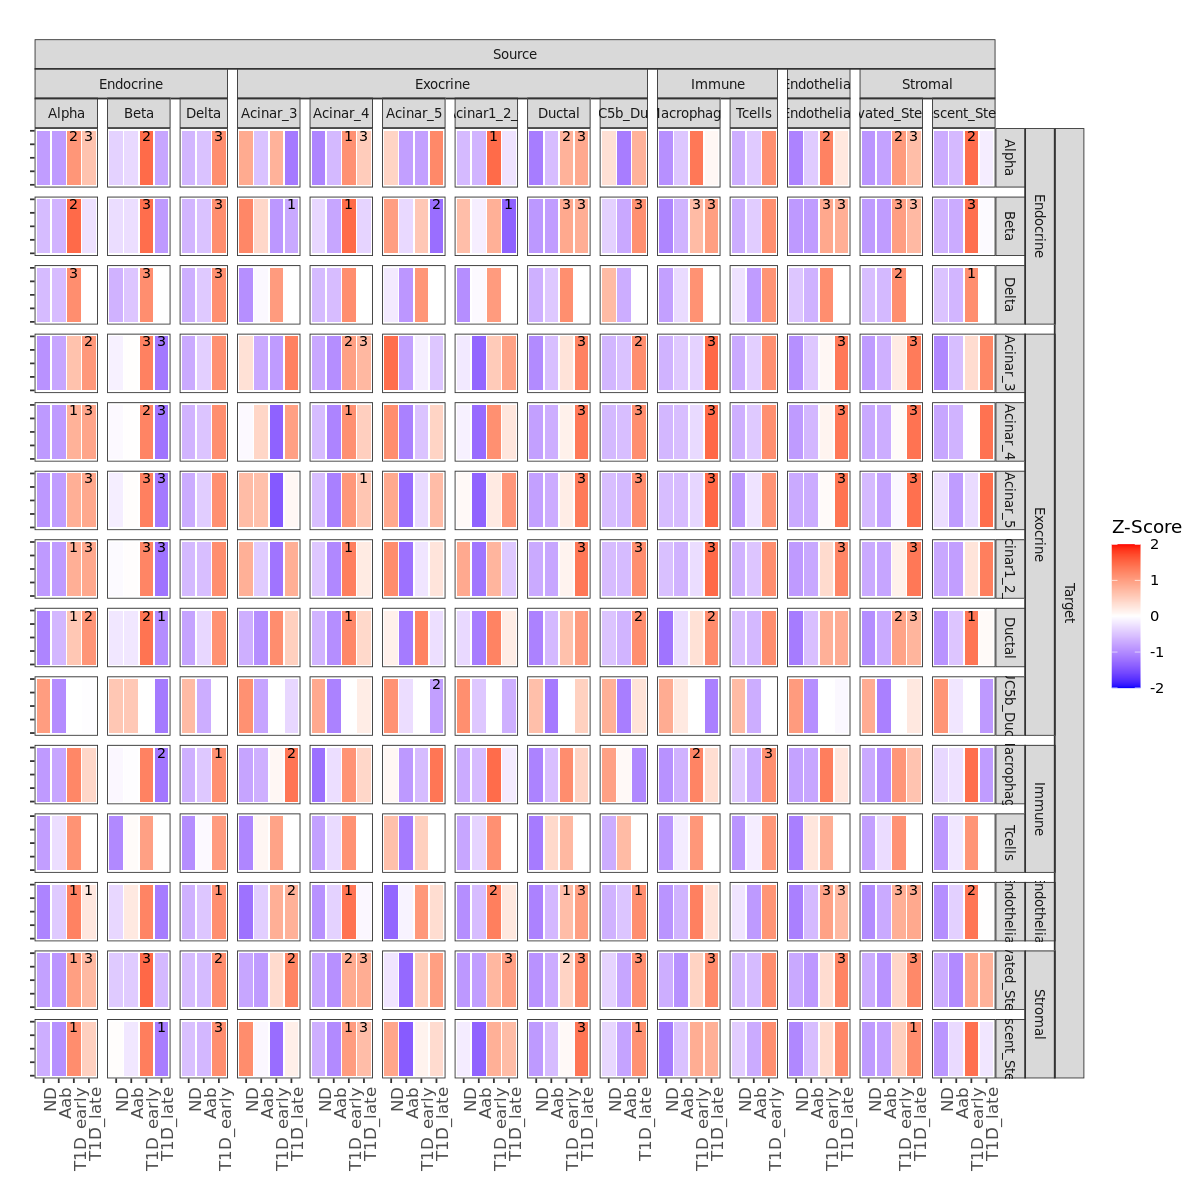

In [21]:
options(repr.plot.width=10, repr.plot.height=10)
ggplot(df_normalized, aes(x = condition, y = y, fill = zscore, label = stars)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_gradient2(low = "blue", high = "red", mid = "white", 
                       midpoint = 0, limit = c(-2,2), space = "Lab",
                       name="Z-Score")+
  theme_bw() +
  theme(panel.grid = element_blank(),
        axis.text.y = element_blank(),
            strip.text.x = element_text(size = 8),
            strip.text.y = element_text(size = 8),        
        axis.text.x = element_text(angle = 90, hjust = 1, size = 10)) +  
  labs(x = "", y = "", fill = "Condition", title = "") +
  facet_nested(cols = vars("Source", compartment.source, source),
               rows = vars("Target", compartment.target, target), scales = "free", space = "free")+
                  geom_text(vjust = 1, size = 3)

In [22]:
# Plot changes by compartment

# Plot All cellpairs Outgoing from one cell

In [23]:
cell.pop.order

[1] "Alpha"              "Beta"               "Delta"             
 [4] "Acinar1_2_6"        "Acinar_3"           "Acinar_4"          
 [7] "Acinar_5"           "Ductal"             "MUC5b_Ductal"      
[10] "Tcells"             "Macrophage"         "Endothelial"       
[13] "Activated_Stellate" "Quiescent_Stellate"

In [24]:
cell.use = "Beta"

In [25]:
data = df_normalized.write
# Convert stars
data$stars = gsub(data$stars, pattern = "3", replacement = "***")
data$stars = gsub(data$stars, pattern = "2", replacement = " **")
data$stars = gsub(data$stars, pattern = "1", replacement = " * ")

# Complete dataframe
data = filter(data, source == cell.use) %>%
       complete(target, condition, nesting(), 
                fill = list(prob.norm = 0,
                            source = cell.use))
data$compartment.target = Cellpop.compartment$compartment[match(data$target,
                                                      Cellpop.compartment$Celltype)]
data$compartment.source = Cellpop.compartment$compartment[match(data$source,
                                                      Cellpop.compartment$Celltype)]
# factorize
data$condition = factor(data$condition, levels = rev(condition.ls))
data$target = factor(data$target, levels = rev.cell.pop.order)
data$source = factor(data$source, levels = rev.cell.pop.order)

# Create combined column
data$source.target = paste0(data$source, "-->", data$target)
ordered_levels <- levels(data$target)
source_target_levels <- paste0(cell.use, "-->", ordered_levels)

# order new column based on target or source
data$source.target <- factor(data$source.target, levels = source_target_levels)

ERROR: Error in eval(expr, envir, enclos): object 'df_normalized.write' not found


In [ ]:
head(data, n = 2)
max(data$prob.norm)

In [ ]:
options(repr.plot.width=8, repr.plot.height=15)
ggplot(data, aes(x = source.target, y = prob.norm, fill = condition, label = stars)) +
  geom_bar(stat = "identity", position = "dodge",
           colour="black", linewidth = 0.5, width = 0.8)+
  theme_bw() +
  theme(panel.grid = element_blank(),
        strip.text.x = element_text(size = 12),
        strip.text.y = element_text(size = 12),
        axis.text.x = element_text(angle = 90, hjust = 1, size = 12),
        axis.text.y = element_text(size = 12),
        plot.title = element_text(hjust = 0.5,face = "bold")) +  
  labs(x = "", y = "\n Normalized IS \n ", fill = "Condition", 
       title = paste0("")) +
  ylim(0, 0.30)+
  facet_nested(rows = vars(compartment.target),
               scales = "free", space = "free") +
  geom_text(hjust = - 0.5, size = 2, position = position_dodge(width = 0.8))  + 
  scale_fill_manual(values = colors.conditions) + 
  coord_flip()

# Plot All cellpairs incoming int one cell

In [82]:
cell.use = "Beta"

In [83]:
data = df_normalized.write
# Convert stars
data$stars = gsub(data$stars, pattern = "3", replacement = "***")
data$stars = gsub(data$stars, pattern = "2", replacement = " **")
data$stars = gsub(data$stars, pattern = "1", replacement = " * ")

# Complete dataframe
data = filter(data, target == cell.use) %>%
       complete(source, condition, nesting(), 
                fill = list(prob.norm = 0,
                            target = cell.use))
data$compartment.target = Cellpop.compartment$compartment[match(data$target,
                                                      Cellpop.compartment$Celltype)]
data$compartment.source = Cellpop.compartment$compartment[match(data$source,
                                                      Cellpop.compartment$Celltype)]
# factorize
data$condition = factor(data$condition, levels = rev(condition.ls))
data$target = factor(data$target, levels = rev.cell.pop.order)
data$source = factor(data$source, levels = rev.cell.pop.order)

# Create combined column
data$source.target = paste0(data$source, "-->", data$target)
ordered_levels <- levels(data$target)
source_target_levels <- paste0(ordered_levels, "-->", cell.use)

# order new column based on target or source
data$source.target <- factor(data$source.target, levels = source_target_levels)

In [84]:
ordered_levels
source_target_levels

[1] "Quiescent_Stellate" "Activated_Stellate" "Endothelial"       
 [4] "Macrophage"         "Tcells"             "MUC5b_Ductal"      
 [7] "Ductal"             "Acinar_5"           "Acinar_4"          
[10] "Acinar_3"           "Acinar1_2_6"        "Delta"             
[13] "Beta"               "Alpha"

[1] "Quiescent_Stellate-->Beta" "Activated_Stellate-->Beta"
 [3] "Endothelial-->Beta"        "Macrophage-->Beta"        
 [5] "Tcells-->Beta"             "MUC5b_Ductal-->Beta"      
 [7] "Ductal-->Beta"             "Acinar_5-->Beta"          
 [9] "Acinar_4-->Beta"           "Acinar_3-->Beta"          
[11] "Acinar1_2_6-->Beta"        "Delta-->Beta"             
[13] "Beta-->Beta"               "Alpha-->Beta"

In [85]:
head(data, n = 2)
max(data$prob.norm)

source,condition,target,source.target,compartment.source,compartment.target,prob.norm,zscore,stars
<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,"<dbl[,1]>",<chr>
Acinar_3,ND,Beta,Acinar_3-->Beta,Exocrine,Endocrine,0.03963998,1.2172100,
Acinar_3,Aab,Beta,Acinar_3-->Beta,Exocrine,Endocrine,0.02647720,0.4156593,


[1] 0.4052478

Warning message:
“Removed 3 rows containing missing values (`geom_text()`).”


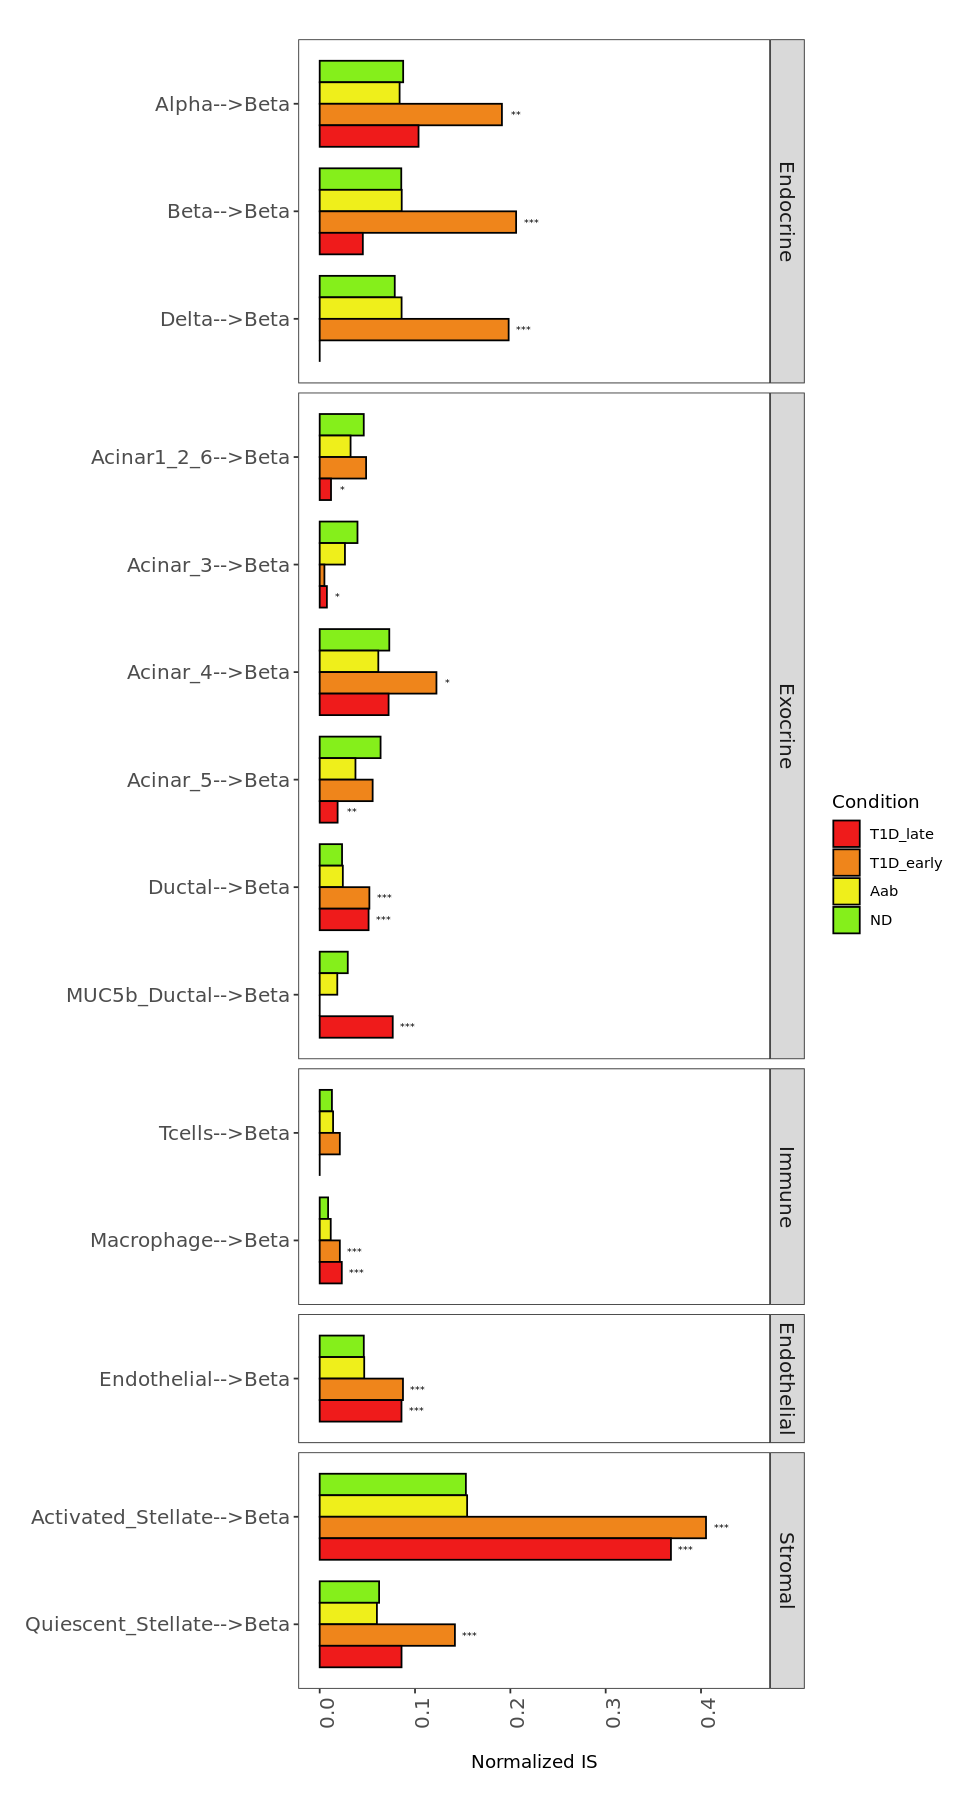

In [87]:
options(repr.plot.width=8, repr.plot.height=15)
gg1 = ggplot(data, aes(x = source.target, y = prob.norm, fill = condition, label = stars)) +
  geom_bar(stat = "identity", position = "dodge",
           colour="black", linewidth = 0.5, width = 0.8)+
  theme_bw() +
  theme(panel.grid = element_blank(),
        strip.text.x = element_text(size = 12),
        strip.text.y = element_text(size = 12),
        axis.text.x = element_text(angle = 90, hjust = 1, size = 12),
        axis.text.y = element_text(size = 12),
        plot.title = element_text(hjust = 0.5,face = "bold")) +  
  labs(x = "", y = "\n Normalized IS \n ", fill = "Condition", 
       title = paste0("")) +
  ylim(0, 0.45)+
  facet_nested(rows = vars(compartment.source),
               scales = "free", space = "free") +
  geom_text(hjust = - 0.5, size = 2, position = position_dodge(width = 0.8))  + 
  scale_fill_manual(values = colors.conditions) + 
  coord_flip()
gg1

In [89]:
file = paste(permutations.test.res.dir, "Allconditions_Incoming_Beta.pdf", sep = "")
ggsave(file, gg1,
       width = 8, height = 15, 
       device = "pdf")

Warning message:
“Removed 3 rows containing missing values (`geom_text()`).”


# Plot top and significant cell pairs


In [90]:
df_normalized.write = select(df_normalized, 
                      source, target, source.target, compartment.source, compartment.target, condition, prob.norm, zscore, "stars")


file.name = paste(permutations.test.res.dir, "Permutation.test_cellpairs.data.res", sep = "")
write.table(df_normalized.write, file.name, sep = "\t", quote = F, col.names=T, row.names = T) 

In [91]:
significant_changes <- df_normalized.write %>%
    group_by(condition) %>%
    filter(stars != "")

In [92]:
df_normalized.write.sig = rbind(significant_changes, 
    filter(df_normalized.write, condition == "ND" & source.target %in% significant_changes$source.target))

In [93]:
df_normalized.write.sig = filter(df_normalized.write, condition == "ND" | stars != "")
file.name = paste(permutations.test.res.dir, "Permutation.test_cellpairs.data.sig.res", sep = "")
write.table(df_normalized.write.sig, file.name, sep = "\t", quote = F, col.names=T, row.names = T)

In [94]:
head(df_normalized.write.sig, n = 2)

source,target,source.target,compartment.source,compartment.target,condition,prob.norm,zscore,stars
<chr>,<chr>,<chr>,<fct>,<fct>,<fct>,<dbl>,"<dbl[,1]>",<chr>
Acinar_3,Acinar_3,Acinar_3-Acinar_3,Exocrine,Exocrine,ND,0.03867157,0.31832573,
Acinar_3,Acinar_4,Acinar_3-Acinar_4,Exocrine,Exocrine,ND,0.02775483,-0.05181361,


In [95]:
condition.ls

df_normalized.write.sig$condition = factor(df_normalized.write.sig$condition, levels = condition.ls)

mat = filter(df_normalized.write.sig, 
                condition %in% c("ND", "T1D_early") & target == "Beta")

keep <- df_normalized.write.sig %>%
  filter(condition == "T1D_early") %>%
  pull(source.target)

# Filter the original data
mat <- mat %>%
  filter(source.target %in% keep | condition == "T1D_early")

# Separate the data into ND and T1D_early
data_ND <- mat %>% filter(condition == "ND")
data_T1D_early <- mat %>% filter(condition == "T1D_early")

# Join the two data frames on source.target and calculate fold change
fold_change_data <- inner_join(data_T1D_early, data_ND, by = "source.target", suffix = c("_T1D_early", "_ND")) %>%
  mutate(FC = prob.norm_T1D_early / prob.norm_ND) %>%
  mutate(FC_ND = prob.norm_ND / prob.norm_ND)

A = data.frame(fold_change_data$source.target, fold_change_data$source_T1D_early , fold_change_data$target_T1D_early,
               fold_change_data$condition_T1D_early, fold_change_data$prob.norm_T1D_early, fold_change_data$stars_T1D_early,
               fold_change_data$FC, fold_change_data$compartment.source_T1D_early)
B = data.frame(fold_change_data$source.target, fold_change_data$source_ND , fold_change_data$target_ND,
               fold_change_data$condition_ND, fold_change_data$prob.norm_ND, fold_change_data$stars_ND,
               fold_change_data$FC_ND, fold_change_data$compartment.source_ND)
colnames(B) = colnames(A)

data = rbind(A, B)


colnames(data) = c("source.target", "source", "target", "condition", "prob.norm", "stars", "FC", "compartment.source")

[1] "ND"        "Aab"       "T1D_early" "T1D_late"

In [96]:
data$stars = gsub(data$stars, pattern = "3", replacement = "***")
data$stars = gsub(data$stars, pattern = "2", replacement = " **")
data$stars = gsub(data$stars, pattern = "1", replacement = " * ")

In [97]:
data$source.target = gsub(data$source.target, pattern = "-Beta", replacement = "--> Beta")

In [98]:
data

source.target,source,target,condition,prob.norm,stars,FC,compartment.source
<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>,<dbl>,<fct>
Acinar_4--> Beta,Acinar_4,Beta,T1D_early,0.122467062,*,1.677672,Exocrine
Activated_Stellate--> Beta,Activated_Stellate,Beta,T1D_early,0.405247818,***,2.642739,Stromal
Alpha--> Beta,Alpha,Beta,T1D_early,0.191157129,**,2.183179,Endocrine
Beta--> Beta,Beta,Beta,T1D_early,0.206041732,***,2.407883,Endocrine
Delta--> Beta,Delta,Beta,T1D_early,0.198208706,***,2.517559,Endocrine
Ductal--> Beta,Ductal,Beta,T1D_early,0.052119421,***,2.222303,Exocrine
Endothelial--> Beta,Endothelial,Beta,T1D_early,0.087351235,***,1.888556,Endothelial
Macrophage--> Beta,Macrophage,Beta,T1D_early,0.021131147,***,2.397570,Immune
Quiescent_Stellate--> Beta,Quiescent_Stellate,Beta,T1D_early,0.141830831,***,2.275798,Stromal


In [99]:
max(data$FC)

[1] 2.642739

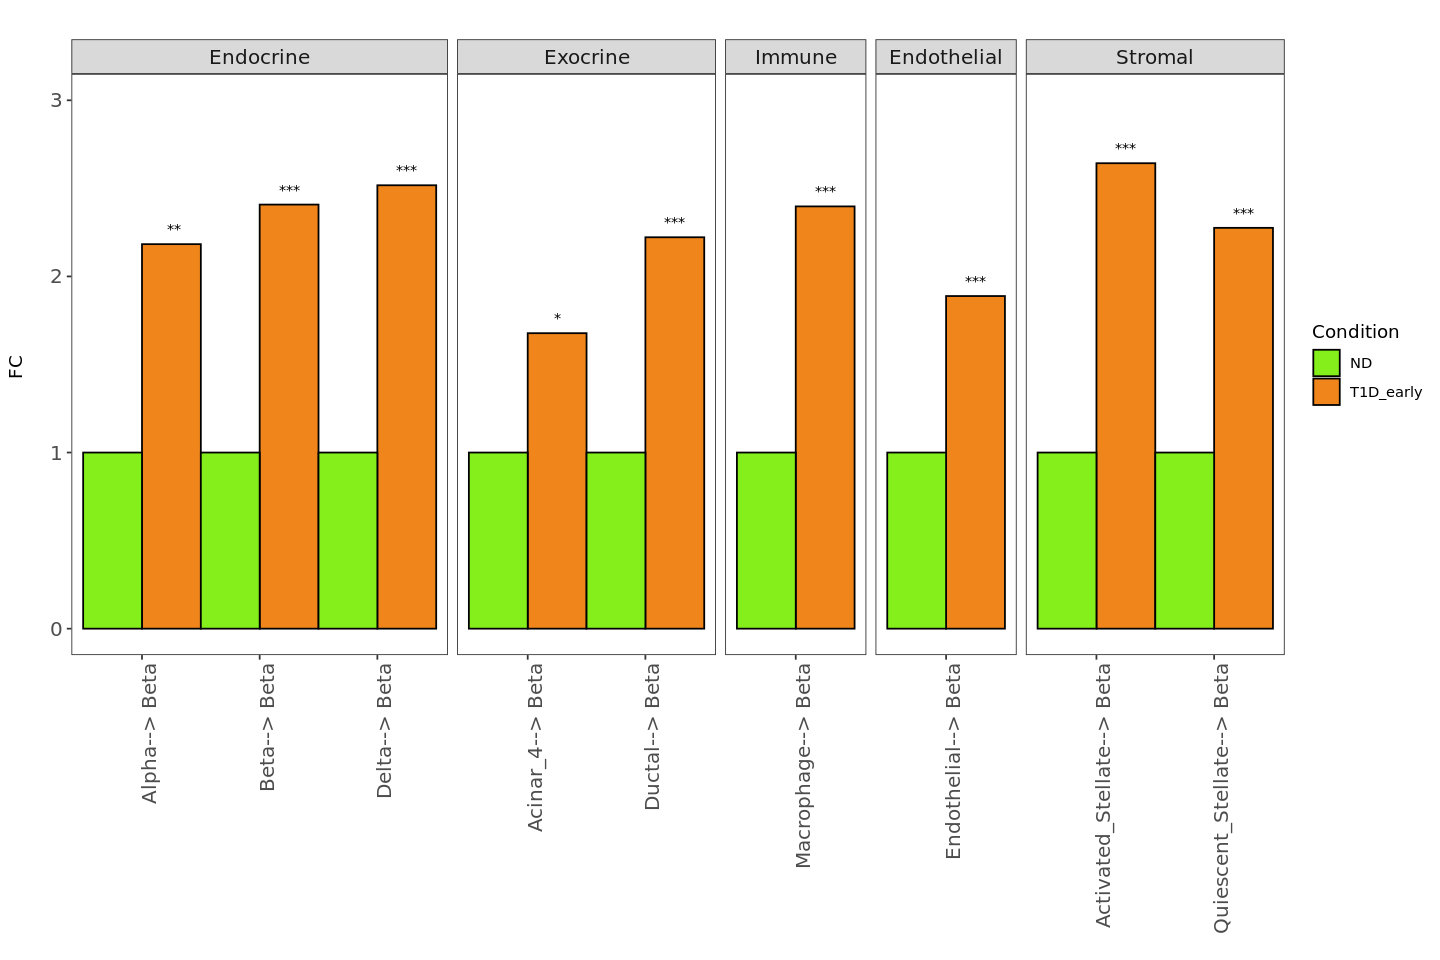

In [102]:
options(repr.plot.width=12, repr.plot.height=8)
gg1 = ggplot(data, aes(x = source.target, y = FC, fill = condition, label = stars)) +
  geom_bar(stat = "identity", position = "dodge", colour="black", linewidth = 0.5, width = 1) +
  theme_bw() +
  theme(panel.grid = element_blank(),
        strip.text.x = element_text(size = 12),
        strip.text.y = element_text(size = 12),
        axis.text.x = element_text(angle = 90, hjust = 1, size = 12),
        axis.text.y = element_text(size = 12),
        plot.title = element_text(hjust = 0.5,face = "bold") 
       ) +  
  labs(x = "", y = "FC \n ", fill = "Condition", 
       title = paste0("")) +
  ylim(0,3)+
  facet_nested(cols = vars(compartment.source),
               scales = "free_x", space = "free") +
  geom_text(vjust = - 1, size = 3, position = position_dodge(width = 1))  + 
  scale_fill_manual(values = colors.conditions)
gg1

In [103]:
file = paste(permutations.test.res.dir, "T1DEarly_ND_Incoming_Beta.pdf", sep = "")
ggsave(file, gg1,
       width = 12, height = 8, 
       device = "pdf")

# choord diagram

In [74]:
results = rbind(diff.obs[[1]], diff.obs[[2]], diff.obs[[3]])
results = results %>%
    dplyr::mutate(source = str_split_fixed(source.target, "-", n = 2)[,1],
                  target = str_split_fixed(source.target, "-", n = 2)[,2]) %>%
    dplyr::filter(!is.na(diff)) %>%
    dplyr::select(source, target, condition, diff, FDR)

results$compartment.target = Cellpop.compartment$compartment[match(results$target,
                                                      Cellpop.compartment$Celltype)]
results$compartment.source = Cellpop.compartment$compartment[match(results$source,
                                                      Cellpop.compartment$Celltype)]
results = dplyr::arrange(results, compartment.source)

# create a combined stat for both FDR and difference magnitude
results$stat = abs(results$diff) * -log(results$FDR)

# Ensure the factor levels are ordered (if necessary)
results$compartment.source <- factor(results$compartment.source, levels = unique(compartment))
results$compartment.target <- factor(results$compartment.target, levels = unique(compartment))

results = dplyr::filter(results, condition == condition.ls[4])
head(results, n = 2)

,source,target,condition,diff,FDR,compartment.target,compartment.source,stat
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<fct>,<dbl>
1,Alpha,Acinar1_2_6,T1D_late,0.02480393,0.0001921569,Exocrine,Endocrine,0.21225219
2,Alpha,Acinar_3,T1D_late,0.02251424,0.0346902655,Exocrine,Endocrine,0.07567701


In [75]:
range(results$diff)

[1] -0.09255681  0.41717642

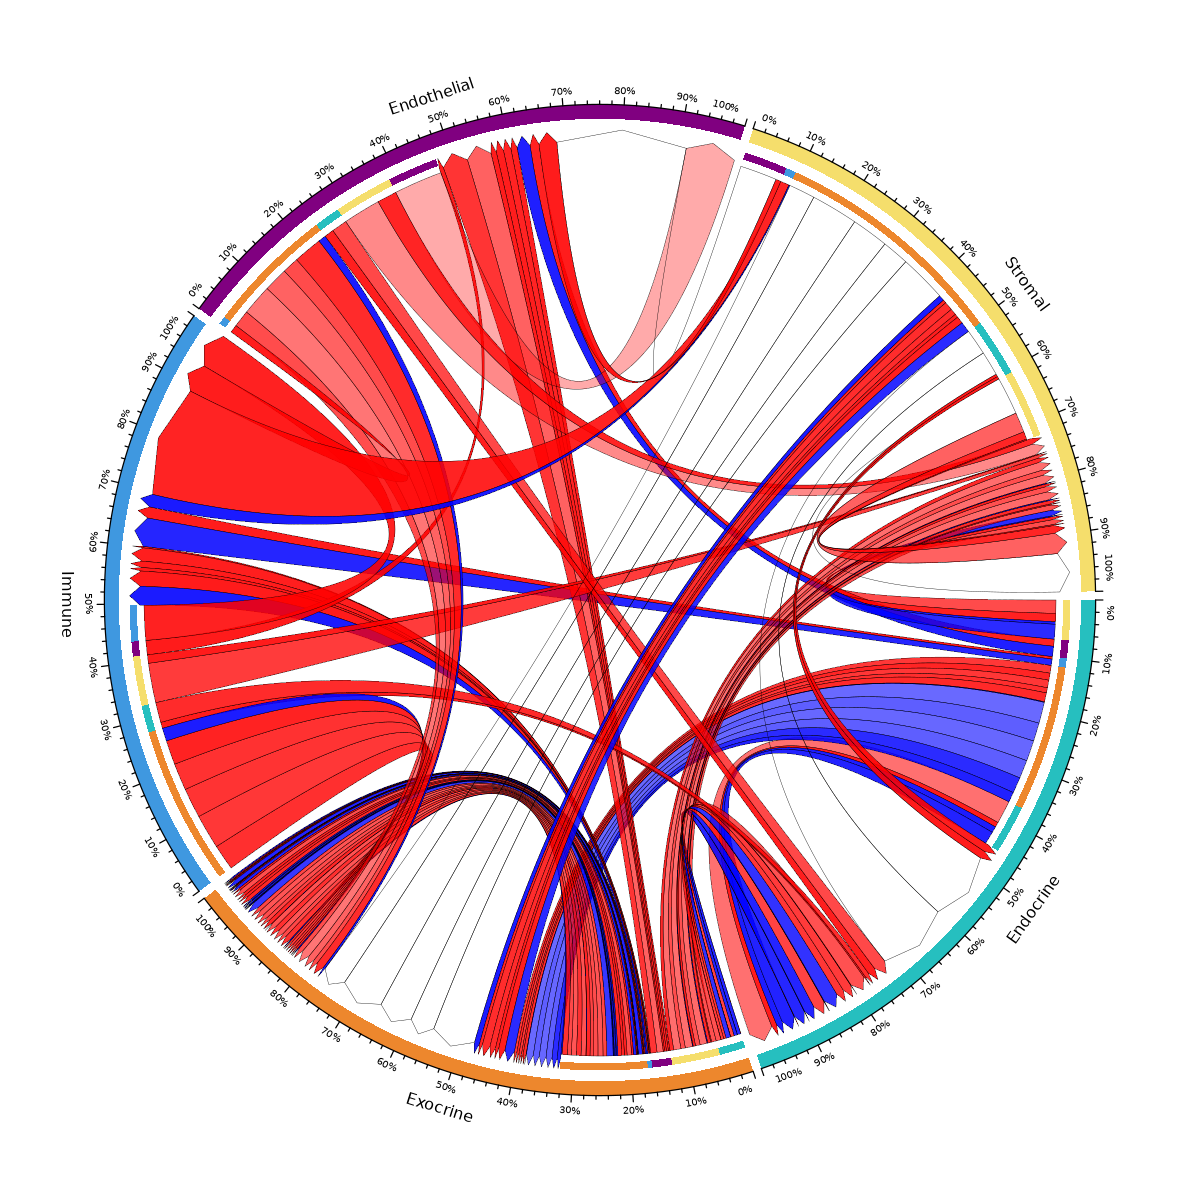

In [76]:
# Create table:
mat = results[, c("compartment.source", "compartment.target", "diff")]

# Define colors based on positive (red) or negative (blue) 'diff' values
results$direction <- ifelse(results$diff > 0, "red", "blue")

# Calculate transparency based on the absolute value of 'diff'

#epsilon <- .Machine$double.eps
#results$transparency <- scales::rescale(results$stat, to = c(0, 1))
#results$transparency <- results$transparency^3  


results$transparency <- scales::rescale(results$stat, to = c(0.1, 2))

# plot
options(repr.plot.width=10, repr.plot.height=10)
chordDiagram(x = mat, scale = TRUE,
            grid.col = colors.compartments[unique(c(results$compartment.source, results$compartment.target))],
            transparency = results$transparency,
            col = results$direction,
            link.border = "black", link.lwd = 0.3, directional = 1, 
            direction.type = c("diffHeight", "arrows"), link.arr.type = "big.arrow")

In [77]:
file = paste(permutations.test.res.dir, "Cellpairs_Coord_LTD.pdf", sep = "")
pdf(file, width = 10, height = 10)

chordDiagram(x = mat, scale = TRUE,
            grid.col = colors.compartments[unique(c(results$compartment.source, results$compartment.target))],
            transparency = results$transparency,
            col = results$direction,
            link.border = "black", link.lwd = 0.3, directional = 1, 
            direction.type = c("diffHeight", "arrows"), link.arr.type = "big.arrow")

# Close the PDF device
dev.off()

png 
  2

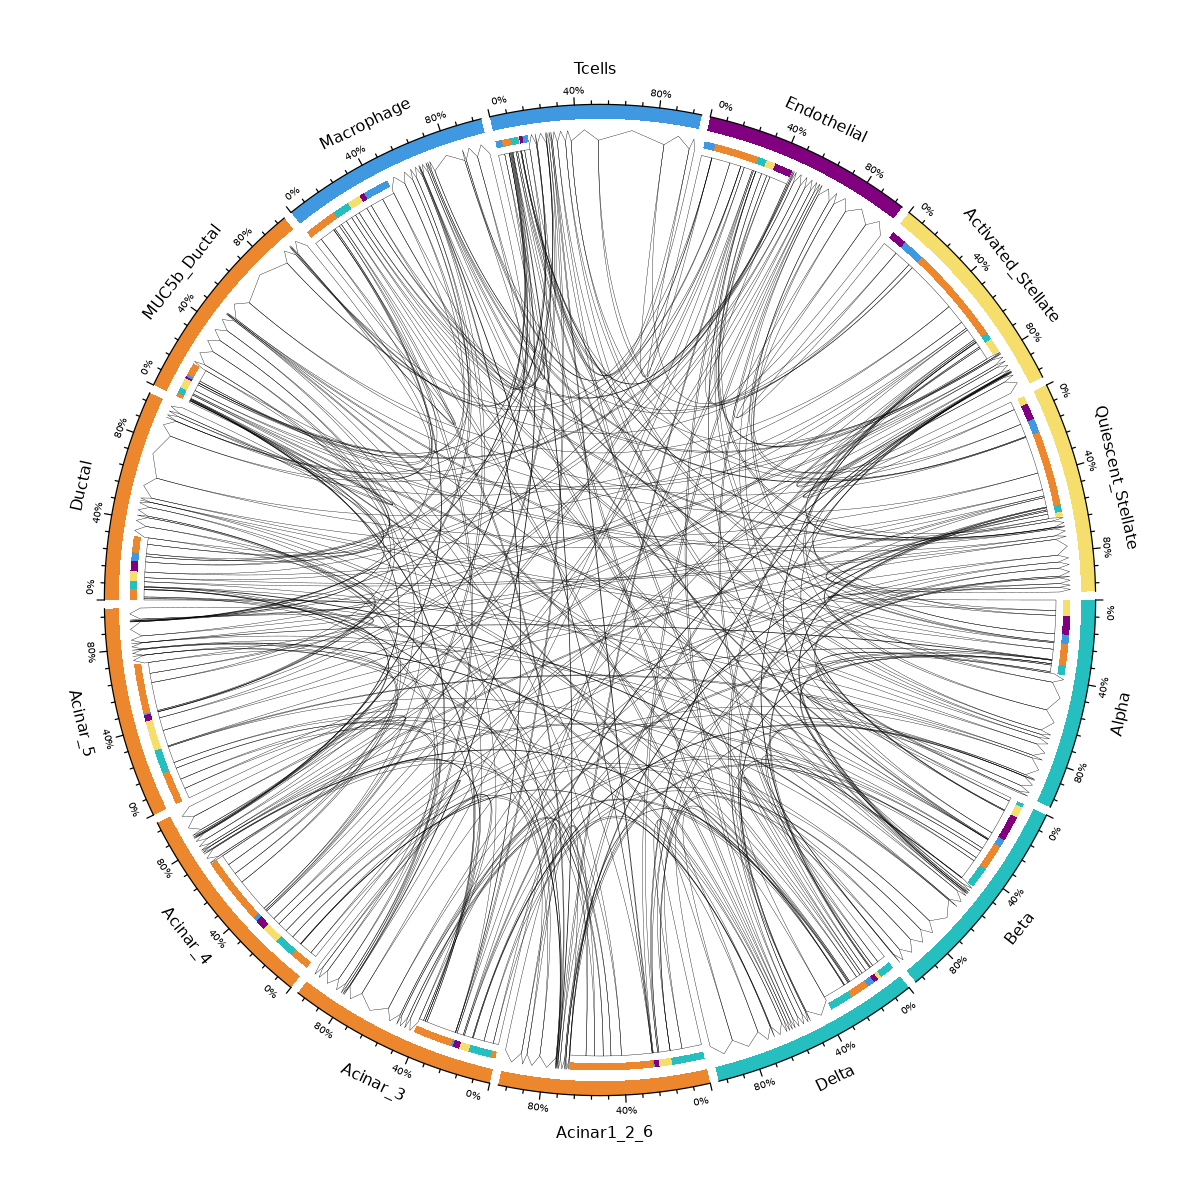

In [68]:
# Create table:
mat = results[, c("source", "target", "diff")]

# Define colors based on positive (red) or negative (blue) 'diff' values
results$direction <- ifelse(results$diff > 0, "red", "blue")

# Calculate transparency based on the absolute value of 'diff'

#epsilon <- .Machine$double.eps
#results$transparency <- scales::rescale(results$stat, to = c(0, 1))
#results$transparency <- results$transparency^3  

results$transparency <- scales::rescale(results$stat, to = c(0.1, 2))

# plot
options(repr.plot.width=10, repr.plot.height=10)
chordDiagram(x = mat, scale = TRUE,
            grid.col = colors.celltypes[unique(c(results$source, results$target))],
            transparency = results$transparency,
            col = results$direction,
            link.border = "black", link.lwd = 0.3, directional = 1, 
            direction.type = c("diffHeight", "arrows"), link.arr.type = "big.arrow")